# **Import Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
sns.set_style("whitegrid")

# **Load Marketing Campaign Dataset**

In [2]:
campaign_data = pd.read_csv("marketing_campaign.csv")
campaign_data.head()

,Unnamed: 0,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,...,7,0,0,0,0,0,0,3,11,1
1,1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,...,5,0,0,0,0,0,0,3,11,0
2,2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,...,4,0,0,0,0,0,0,3,11,0
3,3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,...,6,0,0,0,0,0,0,3,11,0
4,4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,...,5,0,0,0,0,0,0,3,11,0


# **Dataset Structure and Information**

In [3]:
print("Dataset Shape:", campaign_data.shape)
campaign_data.info()

Dataset Shape: (2240, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           2240 non-null   int64  
 1   ID                   2240 non-null   int64  
 2   Year_Birth           2240 non-null   int64  
 3   Education            2240 non-null   object 
 4   Marital_Status       2240 non-null   object 
 5   Income               2216 non-null   float64
 6   Kidhome              2240 non-null   int64  
 7   Teenhome             2240 non-null   int64  
 8   Dt_Customer          2240 non-null   object 
 9   Recency              2240 non-null   int64  
 10  MntWines             2240 non-null   int64  
 11  MntFruits            2240 non-null   int64  
 12  MntMeatProducts      2240 non-null   int64  
 13  MntFishProducts      2240 non-null   int64  
 14  MntSweetProducts     2240 non-null   int64  
 15  MntGoldProds

# **Statistical Summary of Dataset**

In [4]:
campaign_data.describe()

,Unnamed: 0,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,1119.500000,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,646.776623,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,559.750000,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,1119.500000,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,1679.250000,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,2239.000000,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


# **Check Missing Values**

In [5]:
missing_values = campaign_data.isnull().sum()
missing_percentage = (missing_values / len(campaign_data)) * 100
missing_report = pd.DataFrame({"Missing Values": missing_values,"Percentage": missing_percentage})
missing_report.sort_values(by="Missing Values",ascending=False)

,Missing Values,Percentage
Income,24,1.071429
Unnamed: 0,0,0.000000
ID,0,0.000000
Year_Birth,0,0.000000
Education,0,0.000000
Marital_Status,0,0.000000
Kidhome,0,0.000000
Teenhome,0,0.000000
Dt_Customer,0,0.000000
Recency,0,0.000000


# **Handle Missing Income Values**

In [6]:
campaign_data["Income"].fillna(campaign_data["Income"].median(),inplace=True)
campaign_data.isnull().sum()

,0
Unnamed: 0,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0


# **Convert Customer Registration Date**

In [7]:
campaign_data["Dt_Customer"] = pd.to_datetime(campaign_data["Dt_Customer"])
campaign_data["Customer_Year"] = campaign_data["Dt_Customer"].dt.year
campaign_data["Customer_Month"] = campaign_data["Dt_Customer"].dt.month

# **Feature Engineering**

# **Total Product Spending**

In [8]:
campaign_data["Total_Spending"] = (campaign_data["MntWines"]+campaign_data["MntFruits"]+campaign_data["MntMeatProducts"]+campaign_data["MntFishProducts"]+campaign_data["MntSweetProducts"]+campaign_data["MntGoldProds"])

# **Total Purchase Behaviour**

In [9]:
campaign_data["Total_Purchases"] = (campaign_data["NumWebPurchases"]+campaign_data["NumCatalogPurchases"]+campaign_data["NumStorePurchases"])

# **Previous Campaign Acceptance**

In [10]:
campaign_data["Campaign_Acceptance"] = (campaign_data["AcceptedCmp1"]+campaign_data["AcceptedCmp2"]+campaign_data["AcceptedCmp3"]+campaign_data["AcceptedCmp4"]+campaign_data["AcceptedCmp5"])

# **Customer Age Creation**

In [11]:
campaign_data["Age"] = 2025 - campaign_data["Year_Birth"]
campaign_data[["Year_Birth","Age"]].head()

,Year_Birth,Age
0,1957,68
1,1954,71
2,1965,60
3,1984,41
4,1981,44


# **Target Variable Analysis - Campaign Response**

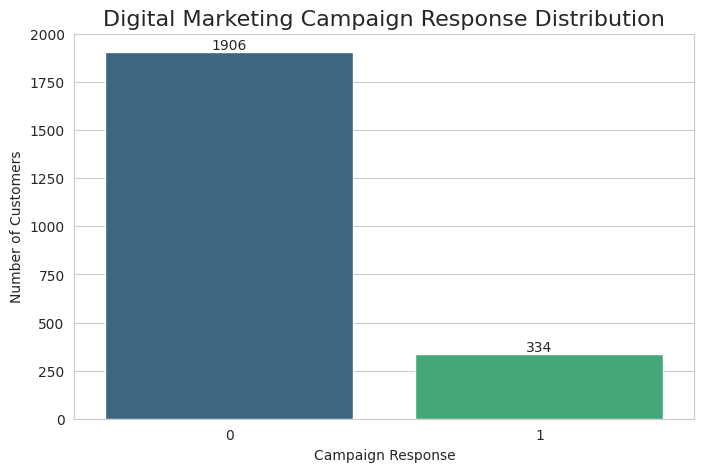

In [12]:
plt.figure(figsize=(8,5))
ax=sns.countplot(data=campaign_data,x="Response",palette="viridis")
plt.title("Digital Marketing Campaign Response Distribution",fontsize=16)
plt.xlabel("Campaign Response")
plt.ylabel("Number of Customers")
for container in ax.containers:
    ax.bar_label(container)
plt.show()

# **Customer Age Distribution**

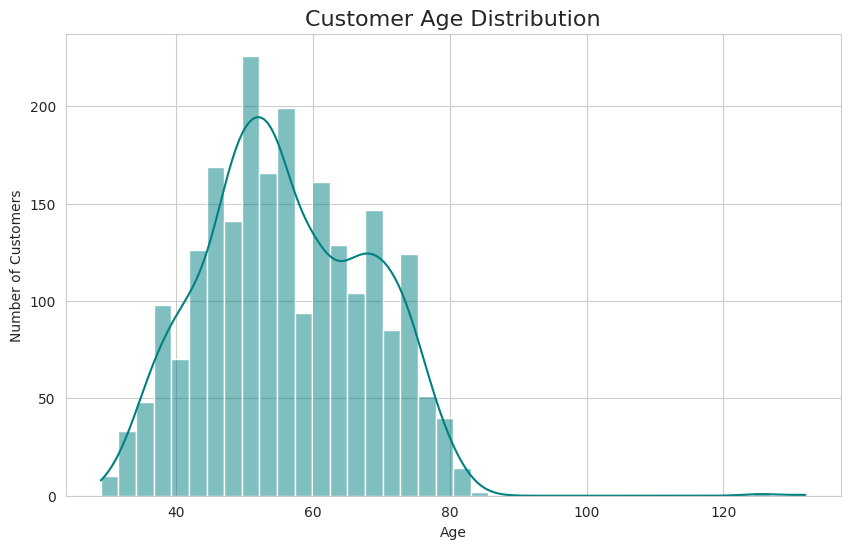

In [13]:
plt.figure(figsize=(10,6))
sns.histplot(data=campaign_data,x="Age",bins=40,kde=True,color="teal")
plt.title("Customer Age Distribution",fontsize=16)
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

# **Income Distribution Analysis**

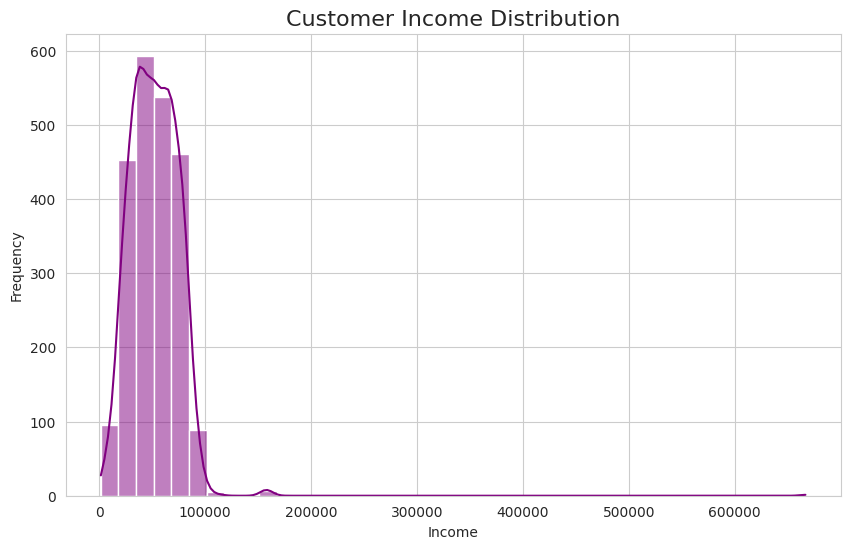

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(data=campaign_data,x="Income",bins=40,kde=True,color="purple")
plt.title("Customer Income Distribution",fontsize=16)
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

# **Education Level Analysis**

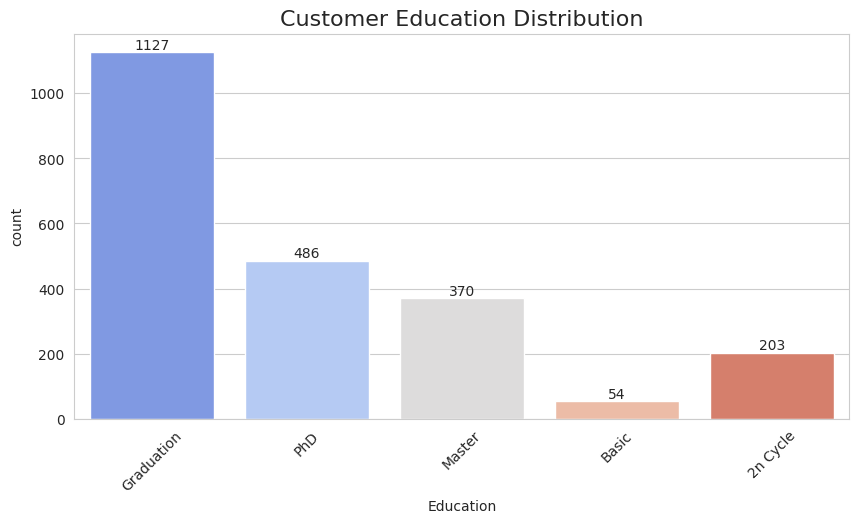

In [15]:
plt.figure(figsize=(10,5))
ax=sns.countplot(data=campaign_data,x="Education",palette="coolwarm")
plt.title("Customer Education Distribution",fontsize=16)
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

# **Marital Status Analysis**

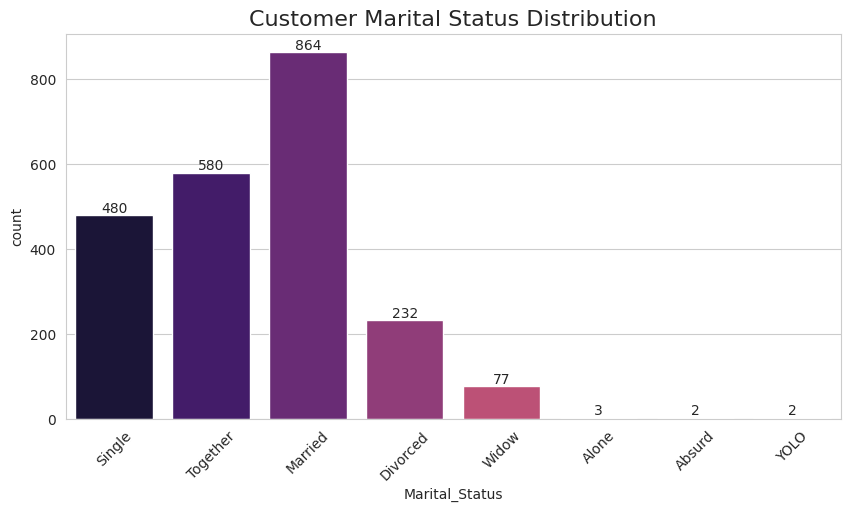

In [16]:
plt.figure(figsize=(10,5))
ax=sns.countplot(data=campaign_data,x="Marital_Status",palette="magma")
plt.title("Customer Marital Status Distribution",fontsize=16)
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

## **Product Category Spending Analysis**

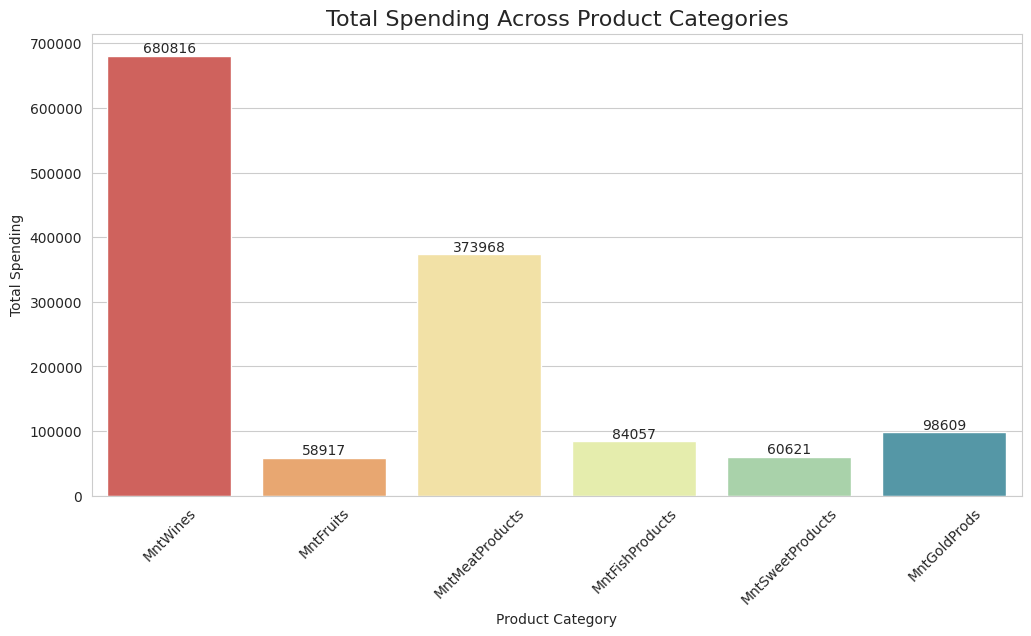

In [17]:
product_columns=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
product_sales=campaign_data[product_columns].sum()
plt.figure(figsize=(12,6))
ax=sns.barplot(x=product_sales.index,y=product_sales.values,palette="Spectral")
plt.title("Total Spending Across Product Categories",fontsize=16)
plt.xlabel("Product Category")
plt.ylabel("Total Spending")
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

# **Purchase Channel Analysis**

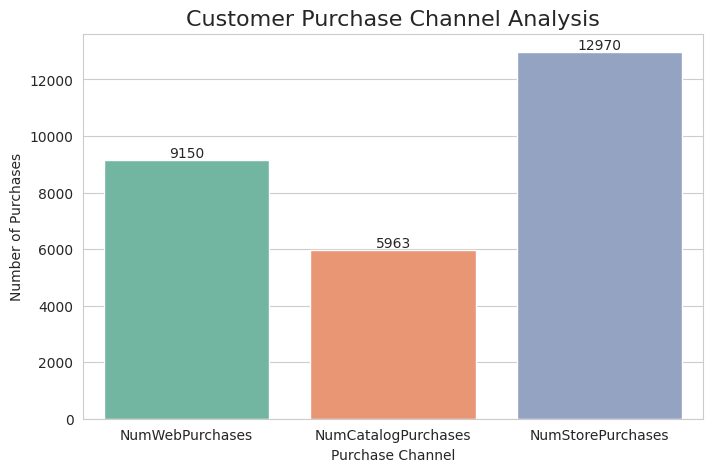

In [18]:
purchase_channels=["NumWebPurchases","NumCatalogPurchases","NumStorePurchases"]
channel_data=campaign_data[purchase_channels].sum()
plt.figure(figsize=(8,5))
ax=sns.barplot(x=channel_data.index,y=channel_data.values,palette="Set2")
plt.title("Customer Purchase Channel Analysis",fontsize=16)
plt.xlabel("Purchase Channel")
plt.ylabel("Number of Purchases")
for container in ax.containers:
    ax.bar_label(container)
plt.show()

# **Correlation Heatmap Analysis**

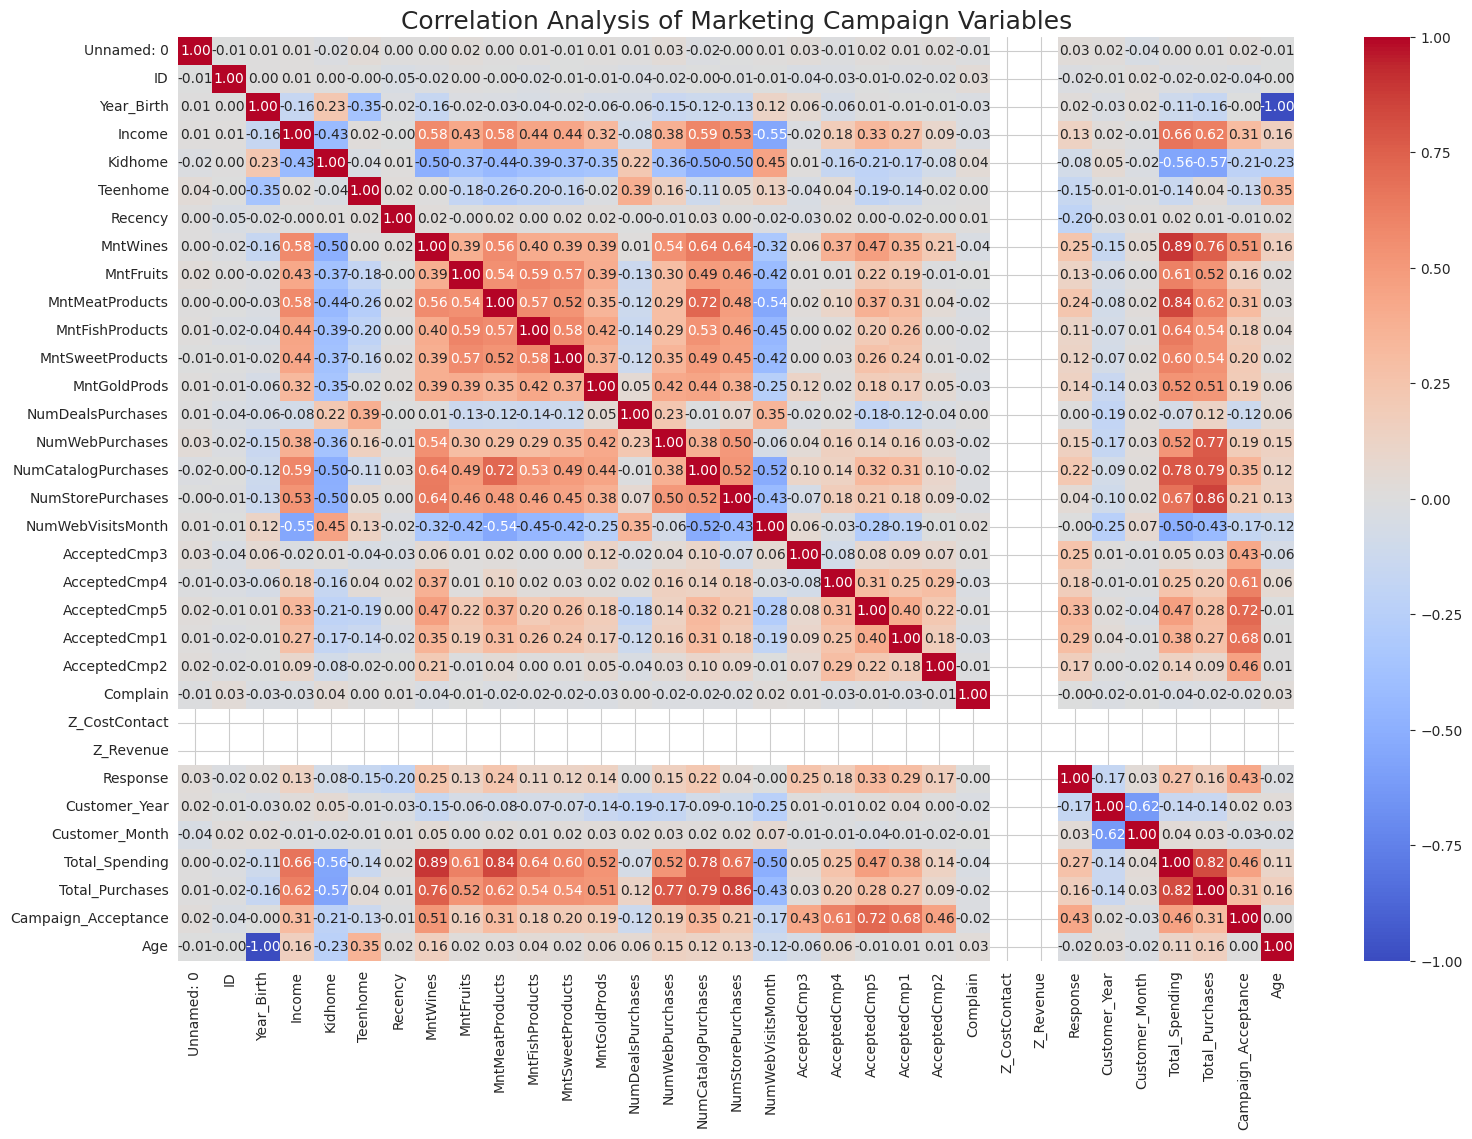

In [19]:
plt.figure(figsize=(18,12))
correlation_matrix=campaign_data.select_dtypes(include=np.number).corr()
sns.heatmap(correlation_matrix,cmap="coolwarm",annot=True,fmt=".2f")
plt.title("Correlation Analysis of Marketing Campaign Variables",fontsize=18)
plt.show()

# **Spending Impact on Campaign Success**

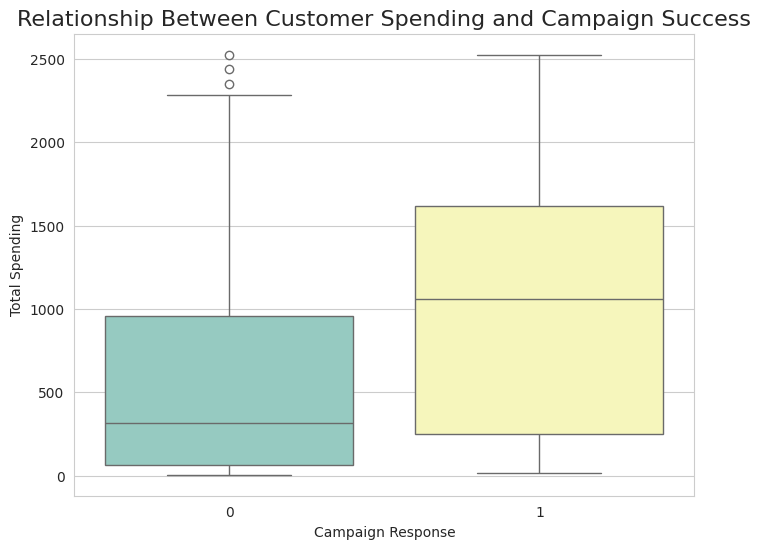

In [20]:
plt.figure(figsize=(8,6))
sns.boxplot(data=campaign_data,x="Response",y="Total_Spending",palette="Set3")
plt.title("Relationship Between Customer Spending and Campaign Success",fontsize=16)
plt.xlabel("Campaign Response")
plt.ylabel("Total Spending")
plt.show()

# **Campaign Acceptance Behaviour**

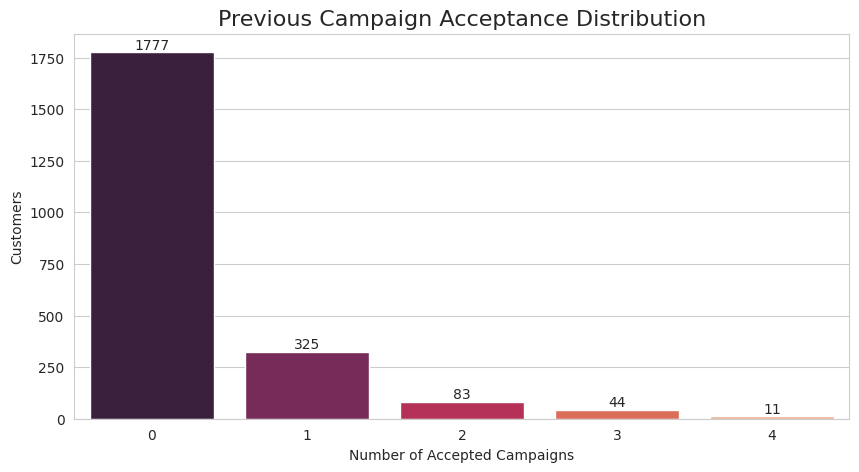

In [21]:
plt.figure(figsize=(10,5))
ax=sns.countplot(data=campaign_data,x="Campaign_Acceptance",palette="rocket")
plt.title("Previous Campaign Acceptance Distribution",fontsize=16)
plt.xlabel("Number of Accepted Campaigns")
plt.ylabel("Customers")
for container in ax.containers:
    ax.bar_label(container)
plt.show()

# **Response Rate by Education**

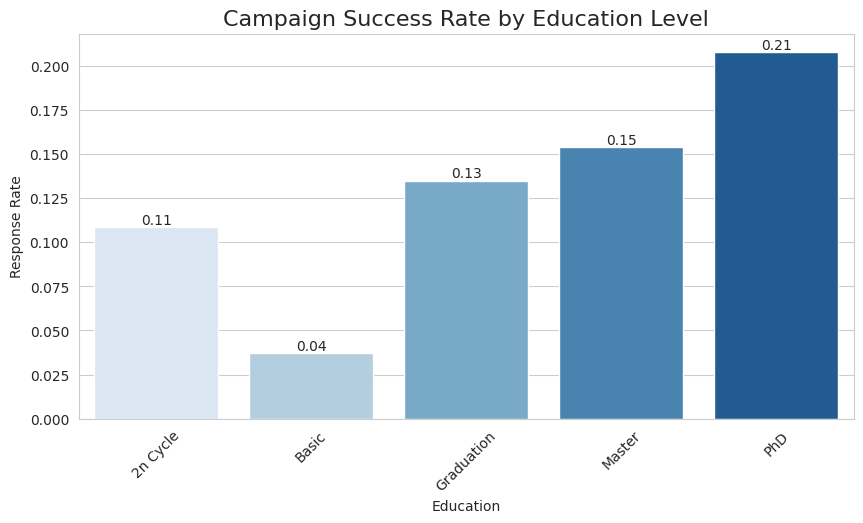

In [22]:
education_response=campaign_data.groupby("Education")["Response"].mean().reset_index()
plt.figure(figsize=(10,5))
ax=sns.barplot(data=education_response,x="Education",y="Response",palette="Blues")
plt.title("Campaign Success Rate by Education Level",fontsize=16)
plt.ylabel("Response Rate")
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container,fmt="%.2f")
plt.show()

# **Encode Categorical Variables**

In [23]:
encoder=LabelEncoder()
categorical_columns=["Education","Marital_Status"]
for column in categorical_columns:
    campaign_data[column]=encoder.fit_transform(campaign_data[column])

# **Define Features and Target Variable**

In [24]:
X=campaign_data.drop("Response",axis=1)
y=campaign_data["Response"]
print("Feature Shape:",X.shape)
print("Target Shape:",y.shape)

Feature Shape: (2240, 35)
Target Shape: (2240,)


# **Train-Test Split**

In [25]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# **Feature Scaling**

In [26]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train.drop(['Dt_Customer'],axis=1))
X_test_scaled=scaler.transform(X_test.drop(['Dt_Customer'],axis=1))

# **Import Machine Learning Libraries**

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report

import matplotlib.pyplot as plt
import seaborn as sns

# **Build Logistic Regression Model**

In [28]:
logistic_model=LogisticRegression(random_state=42,max_iter=1000)
logistic_model.fit(X_train_scaled,y_train)
logistic_prediction=logistic_model.predict(X_test_scaled)

# **Evaluate Logistic Regression Performance**

In [29]:
logistic_accuracy=accuracy_score(y_test,logistic_prediction)
logistic_precision=precision_score(y_test,logistic_prediction)
logistic_recall=recall_score(y_test,logistic_prediction)
logistic_f1=f1_score(y_test,logistic_prediction)

print("Logistic Regression Performance")
print("--------------------------------")
print("Accuracy:",logistic_accuracy)
print("Precision:",logistic_precision)
print("Recall:",logistic_recall)
print("F1 Score:",logistic_f1)

Logistic Regression Performance
--------------------------------
Accuracy: 0.875
Precision: 0.6857142857142857
Recall: 0.34782608695652173
F1 Score: 0.46153846153846156


# **Logistic Regression Classification Report**

In [30]:
print(classification_report(y_test,logistic_prediction))

              precision    recall  f1-score   support

           0       0.89      0.97      0.93       379
           1       0.69      0.35      0.46        69

    accuracy                           0.88       448
   macro avg       0.79      0.66      0.70       448
weighted avg       0.86      0.88      0.86       448



# **Logistic Regression Confusion Matrix**

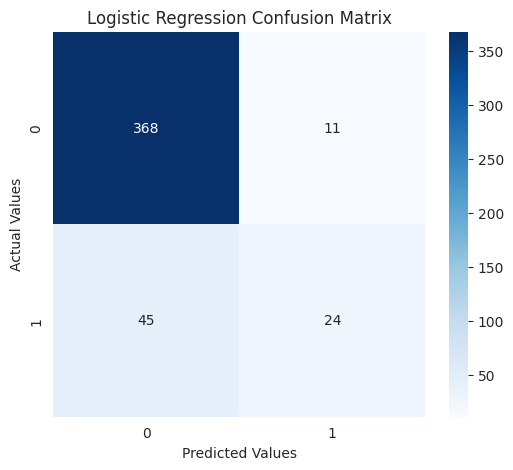

In [31]:
plt.figure(figsize=(6,5))
logistic_cm=confusion_matrix(y_test,logistic_prediction)
sns.heatmap(logistic_cm,annot=True,fmt="d",cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

# **Build Decision Tree Model**

In [32]:
decision_tree_model=DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train.drop(['Dt_Customer'],axis=1),y_train)
decision_tree_prediction=decision_tree_model.predict(X_test.drop(['Dt_Customer'],axis=1))

# **Decision Tree Evaluation**

In [33]:
dt_accuracy=accuracy_score(y_test,decision_tree_prediction)
dt_precision=precision_score(y_test,decision_tree_prediction)
dt_recall=recall_score(y_test,decision_tree_prediction)
dt_f1=f1_score(y_test,decision_tree_prediction)
print("Decision Tree Results")
print("Accuracy:",dt_accuracy)
print("Precision:",dt_precision)
print("Recall:",dt_recall)
print("F1 Score:",dt_f1)

Decision Tree Results
Accuracy: 0.796875
Precision: 0.358974358974359
Recall: 0.4057971014492754
F1 Score: 0.38095238095238093


# **Decision Tree Confusion Matrix**

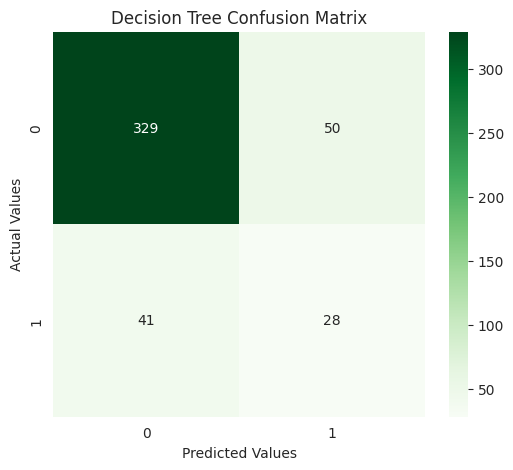

In [34]:
plt.figure(figsize=(6,5))
dt_cm=confusion_matrix(y_test,decision_tree_prediction)
sns.heatmap(dt_cm,annot=True,fmt="d",cmap="Greens")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

# **Random Forest Model Development**

In [35]:
random_forest_model=RandomForestClassifier(n_estimators=100,random_state=42)
random_forest_model.fit(X_train.drop(['Dt_Customer'],axis=1),y_train)
random_forest_prediction=random_forest_model.predict(X_test.drop(['Dt_Customer'],axis=1))

# **Random Forest Evaluation**

In [36]:
rf_accuracy=accuracy_score(y_test,random_forest_prediction)
rf_precision=precision_score(y_test,random_forest_prediction)
rf_recall=recall_score(y_test,random_forest_prediction)
rf_f1=f1_score(y_test,random_forest_prediction)
print("Random Forest Results")
print("Accuracy:",rf_accuracy)
print("Precision:",rf_precision)
print("Recall:",rf_recall)
print("F1 Score:",rf_f1)

Random Forest Results
Accuracy: 0.8660714285714286
Precision: 0.6666666666666666
Recall: 0.2608695652173913
F1 Score: 0.375


# **Compare Machine Learning Models**

In [37]:
model_results=pd.DataFrame({"Model":["Logistic Regression","Decision Tree","Random Forest"],"Accuracy":[logistic_accuracy,dt_accuracy,rf_accuracy],"Precision":[logistic_precision,dt_precision,rf_precision],"Recall":[logistic_recall,dt_recall,rf_recall],"F1 Score":[logistic_f1,dt_f1,rf_f1]})
model_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.875000,0.685714,0.347826,0.461538
1,Decision Tree,0.796875,0.358974,0.405797,0.380952
2,Random Forest,0.866071,0.666667,0.260870,0.375000


# **Model Performance Comparison Chart**

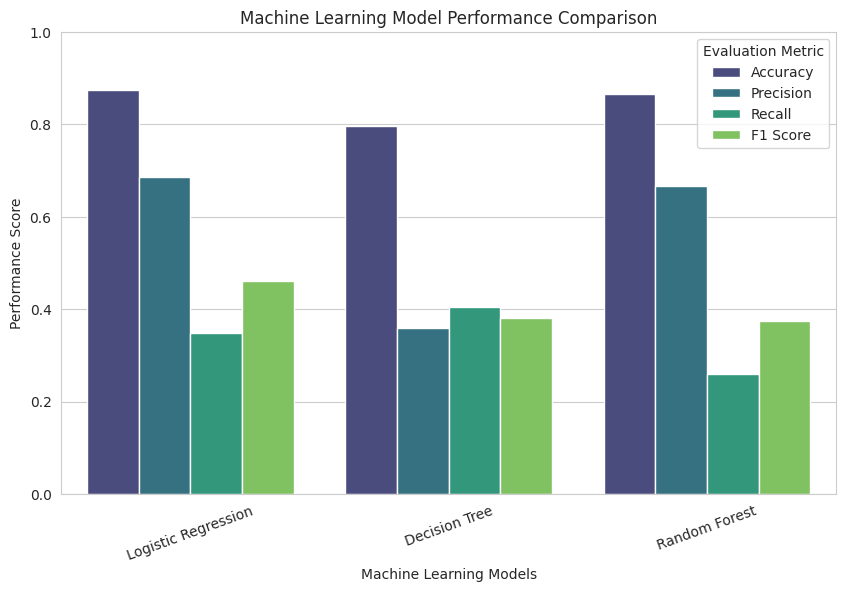

In [38]:
performance_data=model_results.melt(id_vars="Model",var_name="Metric",value_name="Score")
plt.figure(figsize=(10,6))
sns.barplot(data=performance_data,x="Model",y="Score",hue="Metric",palette="viridis")
plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Performance Score")
plt.ylim(0,1)
plt.xticks(rotation=20)
plt.legend(title="Evaluation Metric")
plt.show()

# **Random Forest Feature Importance Analysis**

In [40]:
feature_importance=pd.DataFrame({"Feature":X_train.drop(['Dt_Customer'],axis=1).columns,"Importance":random_forest_model.feature_importances_})
feature_importance=feature_importance.sort_values(by="Importance",ascending=False)
feature_importance.head(15)

,Feature,Importance
8,Recency,0.081504
32,Campaign_Acceptance,0.072101
11,MntMeatProducts,0.050751
5,Income,0.050330
30,Total_Spending,0.049355
9,MntWines,0.047307
0,Unnamed: 0,0.046290
1,ID,0.041842
14,MntGoldProds,0.040562
2,Year_Birth,0.034756


# **Feature Importance Visualisation**

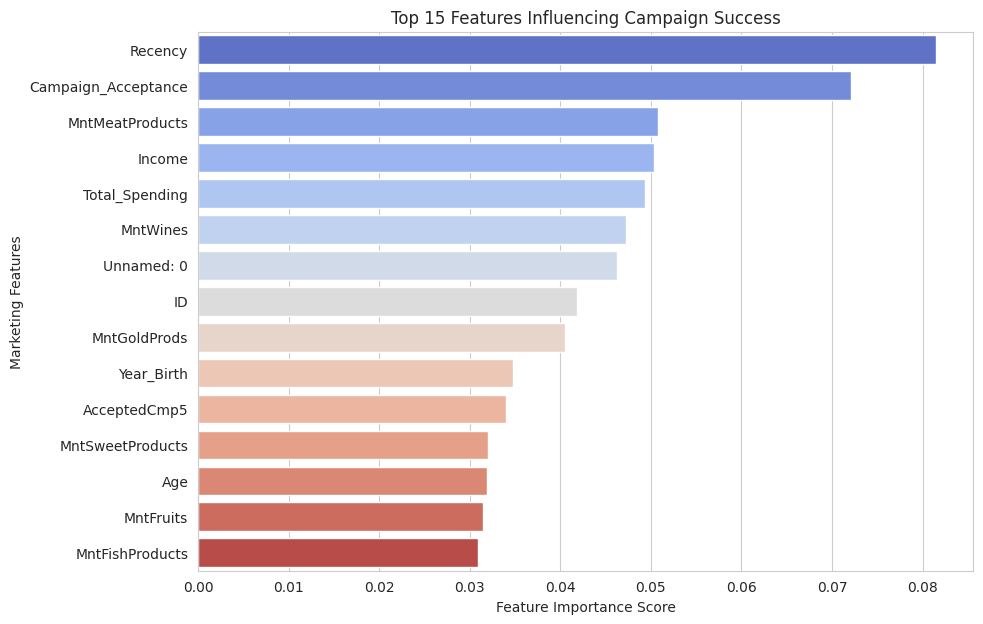

In [41]:
plt.figure(figsize=(10,7))
sns.barplot(data=feature_importance.head(15),x="Importance",y="Feature",palette="coolwarm")
plt.title("Top 15 Features Influencing Campaign Success")
plt.xlabel("Feature Importance Score")
plt.ylabel("Marketing Features")
plt.show()

# **Save Model Evaluation Results**

In [42]:
model_results.to_csv("model_performance_results.csv",index=False)
feature_importance.to_csv("feature_importance_results.csv",index=False)